<a href="https://colab.research.google.com/github/Mnn2kkk6/USD-VND-forecast-15-6-26-31-12-26-/blob/main/USD_VND_LSTM_ARIMA_GARCH_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự báo tỷ giá USD/VND: LSTM (đánh giá ngắn hạn) + ARIMA-GARCH (dự báo dài hạn)

Notebook này thực hiện:
1. Trực quan hóa dữ liệu lịch sử tỷ giá USD/VND (01/01/2024 - 15/06/2026)
2. Huấn luyện mô hình **LSTM** và đánh giá trên tập test (Biểu đồ 2)
3. Dự báo dài hạn (16/06/2026 - 31/12/2026) bằng **ARIMA + GARCH** (Biểu đồ 3 + CSV)

**Tại sao kết hợp ARIMA-GARCH cho dự báo dài hạn?**
- LSTM recursive (lặp) dự báo 199 ngày sẽ bị tích lũy sai số -> giá trị hội tụ về một mức gần như cố định ở các ngày cuối (đường flat).
- **ARIMA** mô hình hóa xu hướng/drift của chuỗi giá theo thời gian.
- **GARCH** mô hình hóa độ biến động (volatility) của lợi suất (returns), dùng để tạo nhiễu ngẫu nhiên có tính chất thống kê thực tế cho từng ngày dự báo.
- Kết hợp 2 mô hình này cho ra một chuỗi dự báo có dao động ngày-qua-ngày tự nhiên hơn, tránh hiện tượng "đứng yên" kéo dài.

**Hướng dẫn sử dụng trên Google Colab:**
- Chạy cell đầu tiên để upload file CSV dữ liệu lịch sử (`Dữ_liệu_Lịch_sử_USD_VND.csv`).
- Chạy tuần tự các cell từ trên xuống dưới.

## 1. Cài đặt thư viện và upload dữ liệu

In [ ]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # Chọn file Dữ_liệu_Lịch_sử_USD_VND.csv

Saving Dữ liệu Lịch sử USD_VND.csv to Dữ liệu Lịch sử USD_VND.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

FILE_NAME = "Dữ_liệu_Lịch_sử_USD_VND.csv"  # Đổi tên nếu file upload có tên khác

## 2. Đọc và xử lý dữ liệu

In [ ]:
FILE_NAME = "Dữ liệu Lịch sử USD_VND.csv" # Corrected filename

df = pd.read_csv(FILE_NAME)
df.columns = [c.strip() for c in df.columns]

# Chuyển cột ngày sang datetime
df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d/%m/%Y')
df = df.sort_values('Ngày').reset_index(drop=True)

# Làm sạch các cột số (loại bỏ dấu phẩy ngăn cách hàng nghìn)
for col in ['Lần cuối', 'Mở', 'Cao', 'Thấp']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

print("Số dòng dữ liệu:", len(df))
print("Khoảng thời gian:", df['Ngày'].min().strftime('%d/%m/%Y'), "->", df['Ngày'].max().strftime('%d/%m/%Y'))
df.head()

Số dòng dữ liệu: 643
Khoảng thời gian: 01/01/2024 -> 15/06/2026


,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,2024-01-01,24260.0,24260.0,24260.0,24260.0,NaN,0.00%
1,2024-01-02,24325.0,24265.0,24337.5,24250.0,NaN,0.27%
2,2024-01-03,24370.0,24345.0,24387.5,24310.0,NaN,0.18%
3,2024-01-04,24360.0,24365.0,24400.0,24357.5,NaN,-0.04%
4,2024-01-05,24370.0,24370.0,24380.0,24337.0,NaN,0.04%


## Biểu đồ 1: Dữ liệu lịch sử tỷ giá USD/VND
Biểu diễn xu hướng tỷ giá theo thời gian trước khi huấn luyện mô hình.

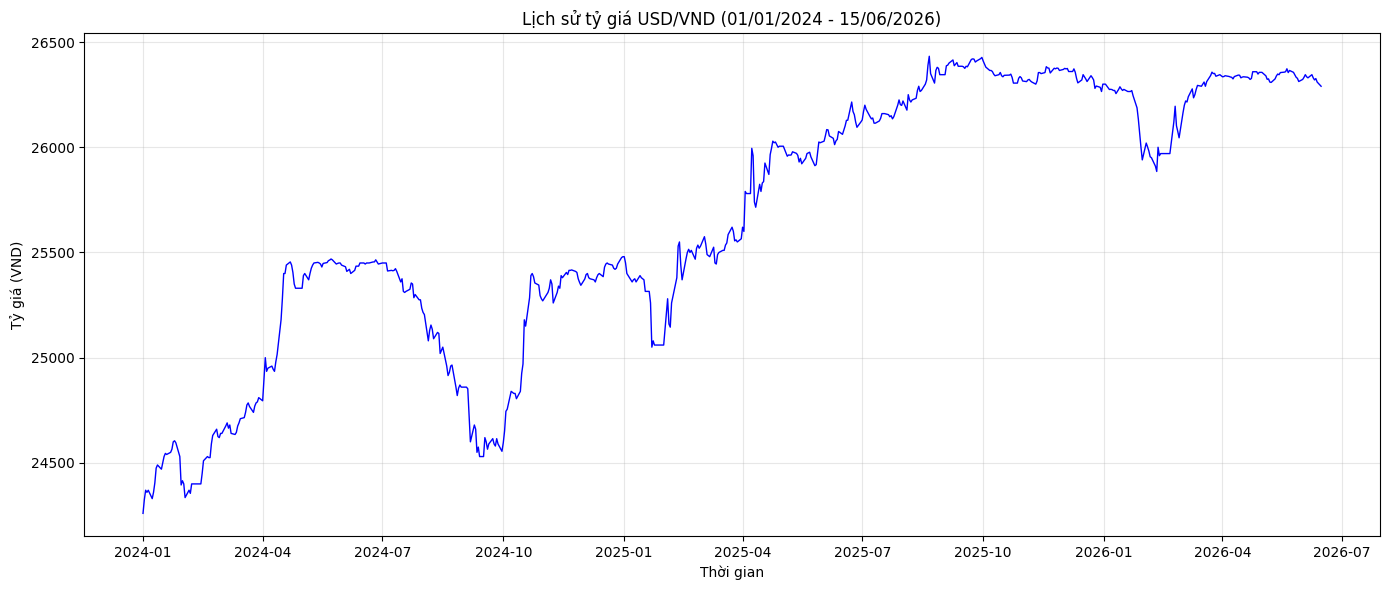

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['Ngày'], df['Lần cuối'], color='blue', linewidth=1)
plt.title('Lịch sử tỷ giá USD/VND (01/01/2024 - 15/06/2026)')
plt.xlabel('Thời gian')
plt.ylabel('Tỷ giá (VND)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_lich_su_ty_gia.png', dpi=150)
plt.show()

## 3. Phần A: LSTM - Đánh giá mô hình trên tập Test

- Dùng cột **"Lần cuối"** (giá đóng) làm dữ liệu chính.
- Chuẩn hóa dữ liệu về khoảng [0,1] với `MinMaxScaler`.
- Cửa sổ trượt (`WINDOW`) gồm 30 ngày trước để dự đoán ngày tiếp theo.
- Chia dữ liệu: 85% train, 15% test (theo thứ tự thời gian, không xáo trộn).

Phần này chỉ dùng để **đánh giá khả năng dự đoán 1 bước (one-step-ahead)** của mô hình, không dùng cho dự báo dài hạn.

In [ ]:
data = df[['Lần cuối']].values
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

WINDOW = 30

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

train_size = int(len(scaled_data) * 0.85)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - WINDOW:]

X_train, y_train = create_sequences(train_data, WINDOW)
X_test, y_test = create_sequences(test_data, WINDOW)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (516, 30, 1) | Test shape: (97, 30, 1)


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0777
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0110
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0090
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0074
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0070
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0072
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0063
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0069
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0065
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0055
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0051
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0051
Epoch 13/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0046
Epoch 14/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0051
Epoch 15/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - lo

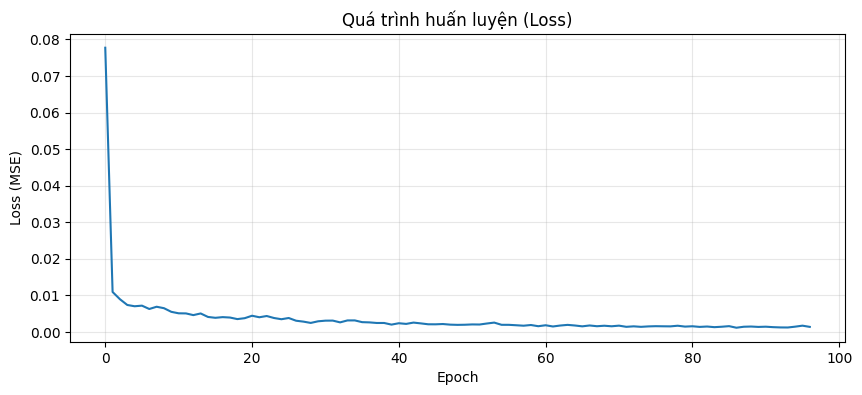

In [ ]:
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'])
plt.title('Quá trình huấn luyện (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(alpha=0.3)
plt.show()

## Biểu đồ 2: So sánh tập Test và dự đoán (LSTM)

- **Đường xanh**: giá thực tế.
- **Đường cam**: giá mô hình dự đoán.

Đây là biểu đồ quan trọng nhất để đánh giá mô hình.

In [ ]:
predicted = model.predict(X_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

test_dates = df['Ngày'].iloc[train_size:].reset_index(drop=True)

# Đánh giá mô hình
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
print(f"RMSE: {rmse:.2f} VND")
print(f"MAE:  {mae:.2f} VND")
print(f"MAPE: {mape:.2f}%")

RMSE: 197.15 VND
MAE:  187.88 VND
MAPE: 0.71%


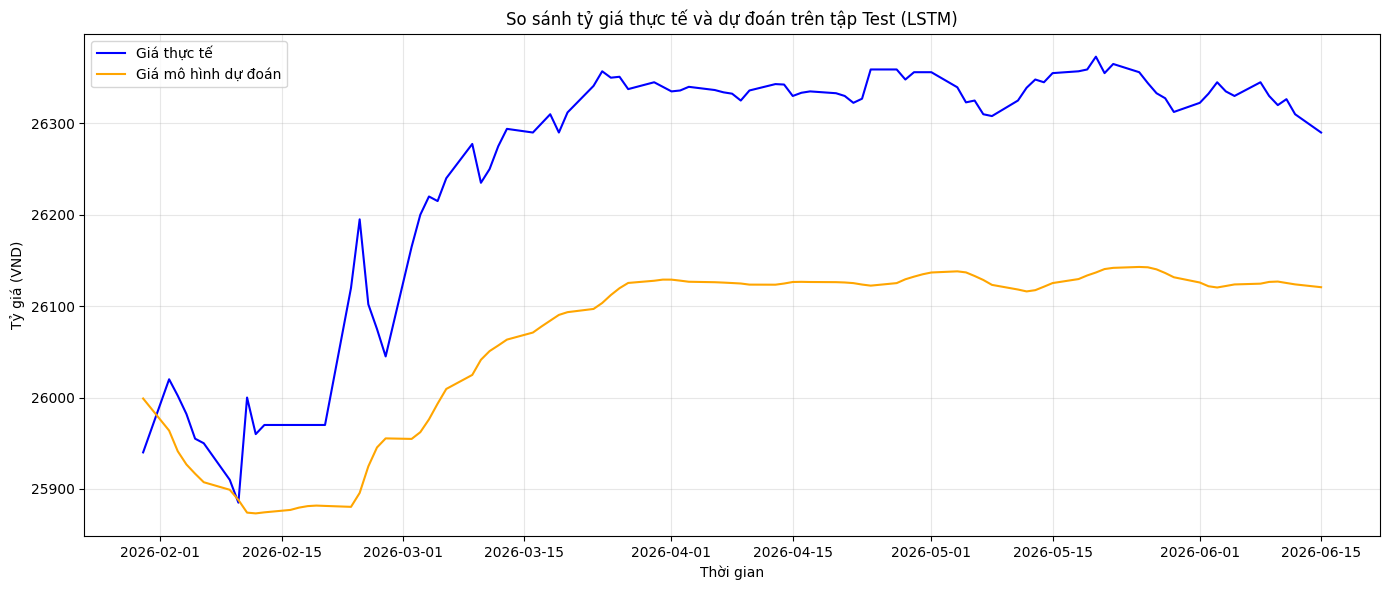

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test_dates, actual_prices, color='blue', label='Giá thực tế', linewidth=1.5)
plt.plot(test_dates, predicted_prices, color='orange', label='Giá mô hình dự đoán', linewidth=1.5)
plt.title('So sánh tỷ giá thực tế và dự đoán trên tập Test (LSTM)')
plt.xlabel('Thời gian')
plt.ylabel('Tỷ giá (VND)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_test_vs_predict.png', dpi=150)
plt.show()

## 4. Phần B: ARIMA + GARCH - Dự báo dài hạn (16/06/2026 - 31/12/2026)

**Phương pháp:**
1. **ARIMA(5,1,0)** trên chuỗi giá gốc -> tạo đường xu hướng (drift) cho 199 ngày tới.
2. **GARCH(1,1)** trên chuỗi log-return -> ước lượng độ biến động (volatility) có điều kiện cho từng ngày tới, volatility tăng dần theo thời gian (đặc trưng của GARCH khi dự báo dài hạn -> phản ánh sự không chắc chắn tăng lên).
3. Kết hợp: dùng volatility từ GARCH để sinh nhiễu ngẫu nhiên (random walk có biên độ theo GARCH), cộng dồn (cumulative) và giảm hệ số (damping factor 0.3) vào đường xu hướng ARIMA.

=> Kết quả: chuỗi dự báo có dao động tự nhiên ngày-qua-ngày, không bị "đứng yên" như LSTM recursive.

In [ ]:
series = df['Lần cuối']

# Log returns (%) cho GARCH
log_returns = np.log(series / series.shift(1)).dropna() * 100

future_dates = pd.date_range(start='2026-06-16', end='2026-12-31', freq='D')
n_future = len(future_dates)
print("Số ngày cần dự báo:", n_future)

Số ngày cần dự báo: 199


In [ ]:
# ARIMA - đường xu hướng (drift)
arima_order = (5, 1, 0)
arima_model = ARIMA(series, order=arima_order).fit()
arima_forecast = arima_model.forecast(steps=n_future)

print("ARIMA forecast (5 ngày đầu):", arima_forecast.values[:5].round(1))
print("ARIMA forecast (5 ngày cuối):", arima_forecast.values[-5:].round(1))

ARIMA forecast (5 ngày đầu): [26289.8 26289.3 26286.5 26285.9 26286. ]
ARIMA forecast (5 ngày cuối): [26285.4 26285.4 26285.4 26285.4 26285.4]


In [ ]:
# GARCH - độ biến động có điều kiện
garch_model = arch_model(log_returns, vol='GARCH', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')
garch_forecast = garch_fit.forecast(horizon=n_future, reindex=False)
cond_vol = garch_forecast.variance.values[-1, :] ** 0.5  # độ lệch chuẩn ngày (đơn vị %)

print("GARCH volatility (5 ngày đầu, %):", cond_vol[:5].round(3))
print("GARCH volatility (5 ngày cuối, %):", cond_vol[-5:].round(3))

GARCH volatility (5 ngày đầu, %): [0.072 0.075 0.078 0.081 0.084]
GARCH volatility (5 ngày cuối, %): [0.301 0.302 0.303 0.303 0.304]


In [ ]:
# Kết hợp ARIMA (xu hướng) + GARCH (nhiễu ngẫu nhiên theo độ biến động)
import io

np.random.seed(42)
DAMPING = 0.3  # hệ số giảm nhiễu, có thể điều chỉnh 0.1 - 0.5

noise_pct = np.random.normal(0, cond_vol / 100, n_future)
noise_cumulative = np.cumsum(noise_pct * arima_forecast.values * DAMPING)

final_forecast = arima_forecast.values + noise_cumulative

# ===== Tạo CSV output có format giống hệt file input =====
# - BOM UTF-8
# - Tất cả fields đều được quote
# - Số dùng dấu phẩy hàng nghìn: 26,292.6
# - Cột KL để trống
# - % Thay đổi không có dấu +

last_actual_close = df['Lần cuối'].iloc[-1]  # giá đóng cửa ngày 15/06/2026
SPREAD_PCT = 0.001  # 0.1% spread cho Cao/Thấp

rows = []
prev_close = last_actual_close

for i, price in enumerate(final_forecast):
    open_ = round(prev_close, 1)
    spread = price * SPREAD_PCT
    high = round(price + abs(np.random.normal(0, spread)), 1)
    low  = round(price - abs(np.random.normal(0, spread)), 1)

    pct_change = (price - prev_close) / prev_close * 100
    if pct_change == 0:
        pct_str = '0.00%'
    elif pct_change > 0:
        pct_str = f'{abs(pct_change):.2f}%'
    else:
        pct_str = f'-{abs(pct_change):.2f}%'

    rows.append({
        'Ngày':        future_dates[i].strftime('%d/%m/%Y'),
        'Lần cuối':   f'{price:,.1f}',
        'Mở':          f'{open_:,.1f}',
        'Cao':          f'{high:,.1f}',
        'Thấp':        f'{low:,.1f}',
        'KL':           '',
        '% Thay đổi':  pct_str
    })
    prev_close = price

forecast_df = pd.DataFrame(rows, columns=['Ngày','Lần cuối','Mở','Cao','Thấp','KL','% Thay đổi'])

# Ghi file với BOM và quote tất cả fields
out_filename = 'forecast_USD_VND_16_06_2026_to_31_12_2026.csv'
buf = io.StringIO()
forecast_df.to_csv(buf, index=False, quoting=1, encoding='utf-8')
csv_str = '\ufeff' + buf.getvalue()
with open(out_filename, 'w', encoding='utf-8') as f:
    f.write(csv_str)

print(f'Đã lưu file: {out_filename}')
print(f'Số dòng: {len(forecast_df)}')
print('\n5 ngày đầu:')
print(forecast_df.head().to_string(index=False))
print('\n5 ngày cuối:')
print(forecast_df.tail().to_string(index=False))


Đã lưu file: forecast_USD_VND_16_06_2026_to_31_12_2026.csv
Số dòng: 199

5 ngày đầu:
      Ngày Lần cuối       Mở      Cao     Thấp KL % Thay đổi
16/06/2026 26,292.6 26,290.0 26,322.7 26,283.2         0.01%
17/06/2026 26,291.3 26,292.6 26,306.1 26,262.8        -0.00%
18/06/2026 26,292.5 26,291.3 26,320.2 26,256.3         0.00%
19/06/2026 26,301.6 26,292.5 26,326.3 26,288.1         0.03%
20/06/2026 26,300.2 26,301.6 26,313.7 26,286.6        -0.01%

5 ngày cuối:
      Ngày Lần cuối       Mở      Cao     Thấp KL % Thay đổi
27/12/2026 26,246.4 26,242.3 26,268.7 26,224.6         0.02%
28/12/2026 26,255.6 26,246.4 26,278.0 26,253.7         0.03%
29/12/2026 26,234.5 26,255.6 26,247.0 26,221.9        -0.08%
30/12/2026 26,238.1 26,234.5 26,246.9 26,210.9         0.01%
31/12/2026 26,239.5 26,238.1 26,252.9 26,232.5         0.01%


## Biểu đồ 3: Dự báo USD/VND đến cuối năm 2026
Kết quả dự báo (ARIMA-GARCH) từ 16/06/2026 đến 31/12/2026.

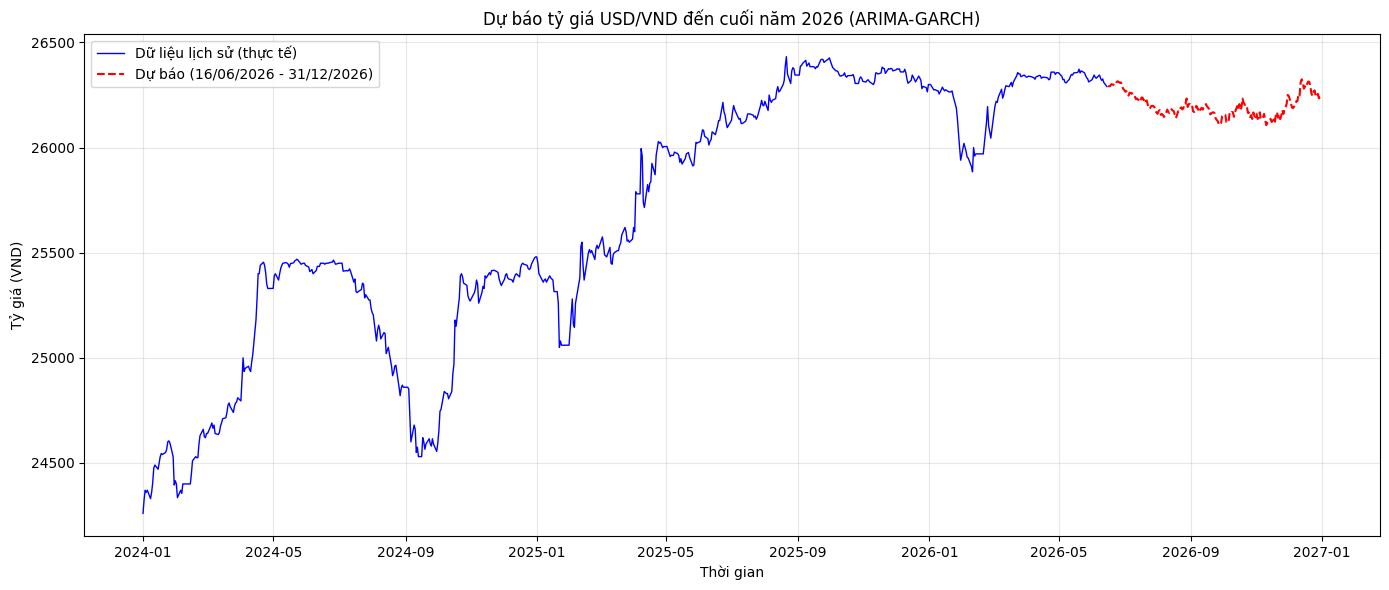

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['Ngày'], df['Lần cuối'], color='blue', label='Dữ liệu lịch sử (thực tế)', linewidth=1)
plt.plot(future_dates, final_forecast, color='red', label='Dự báo (16/06/2026 - 31/12/2026)', linewidth=1.5, linestyle='--')
plt.title('Dự báo tỷ giá USD/VND đến cuối năm 2026 (ARIMA-GARCH)')
plt.xlabel('Thời gian')
plt.ylabel('Tỷ giá (VND)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_du_bao_2026.png', dpi=150)
plt.show()

## 5. Tải file CSV kết quả dự báo (tùy chọn)

In [ ]:
from google.colab import files
files.download('forecast_USD_VND_16_06_2026_to_31_12_2026.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>